[2026-07-05 22:18:14] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-05 22:20:23] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-05 22:20:23] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-05 22:20:25] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-05 22:20:26] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-05 22:20:28] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-05 22:20:28] [info     ] ========== 数据检查 ==========
[2026-07-05 22:20:28] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0197
2024-09-24~2024-10-08,0.0210

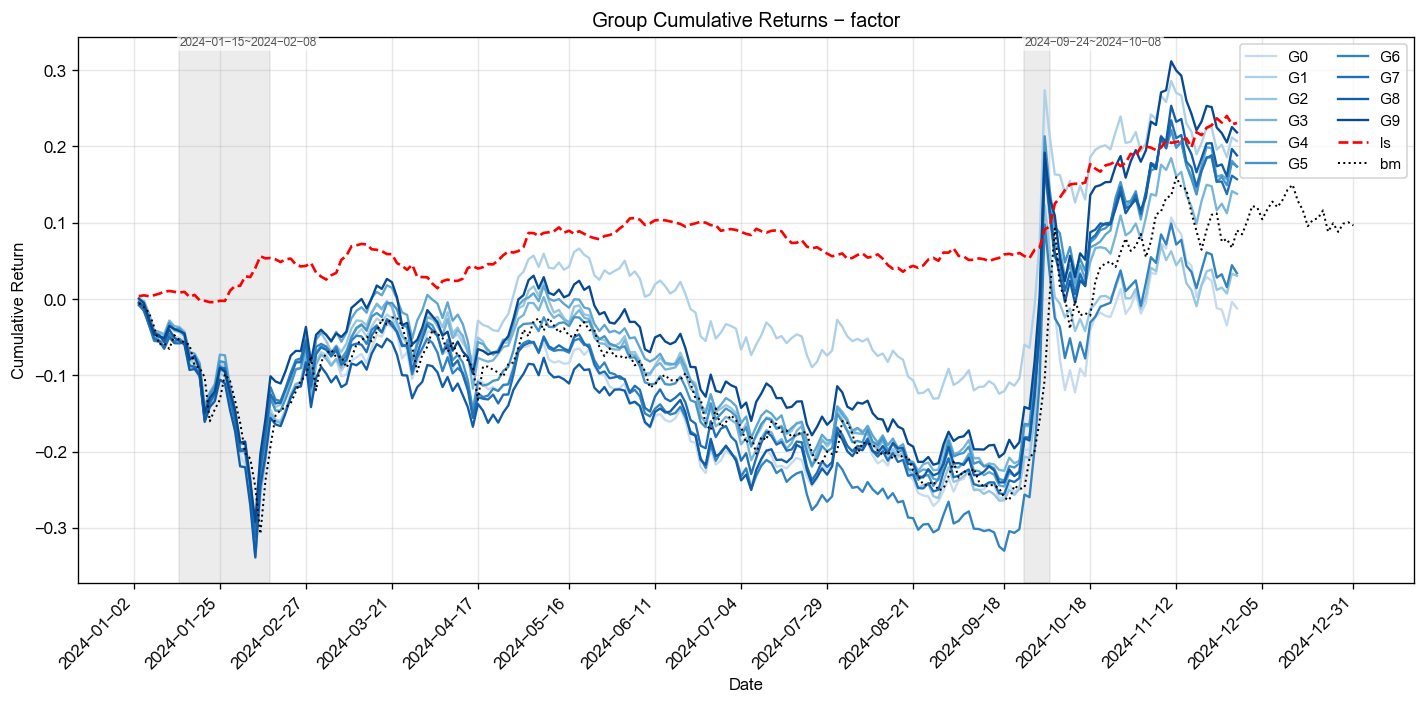
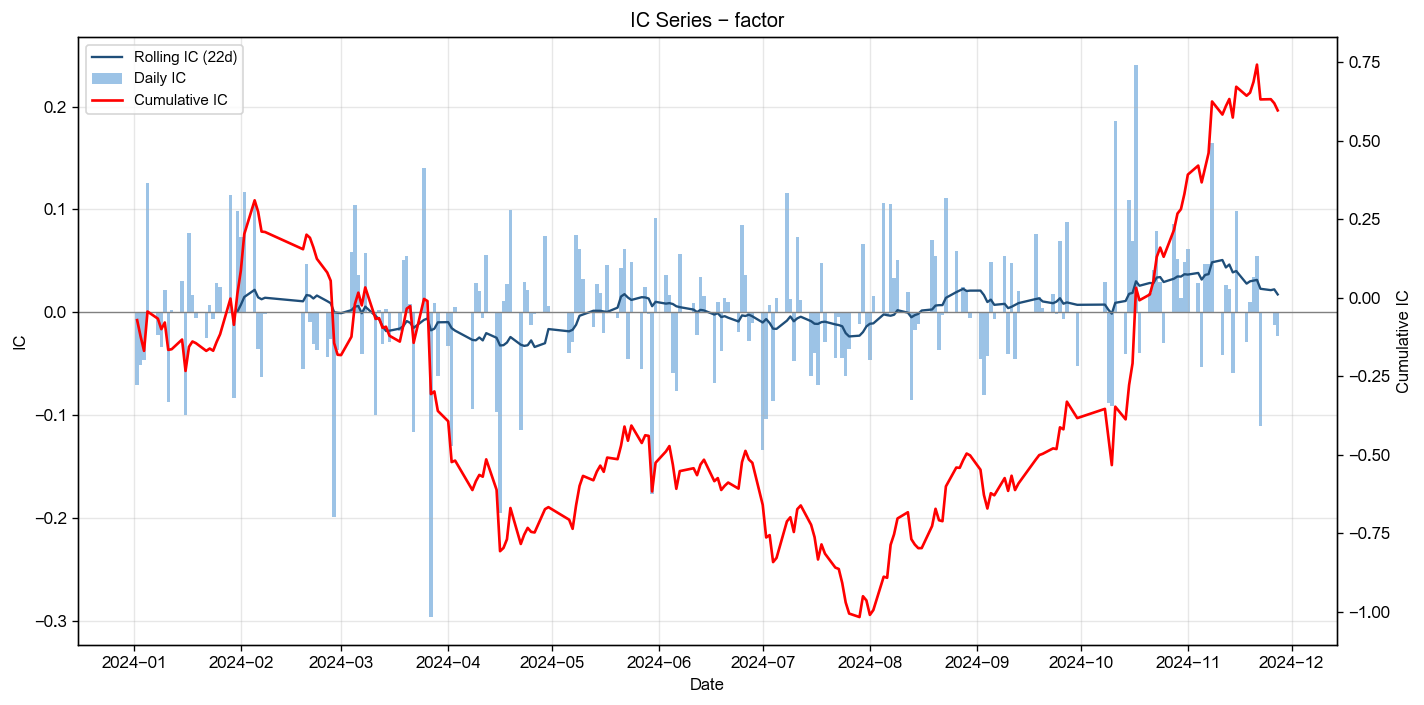
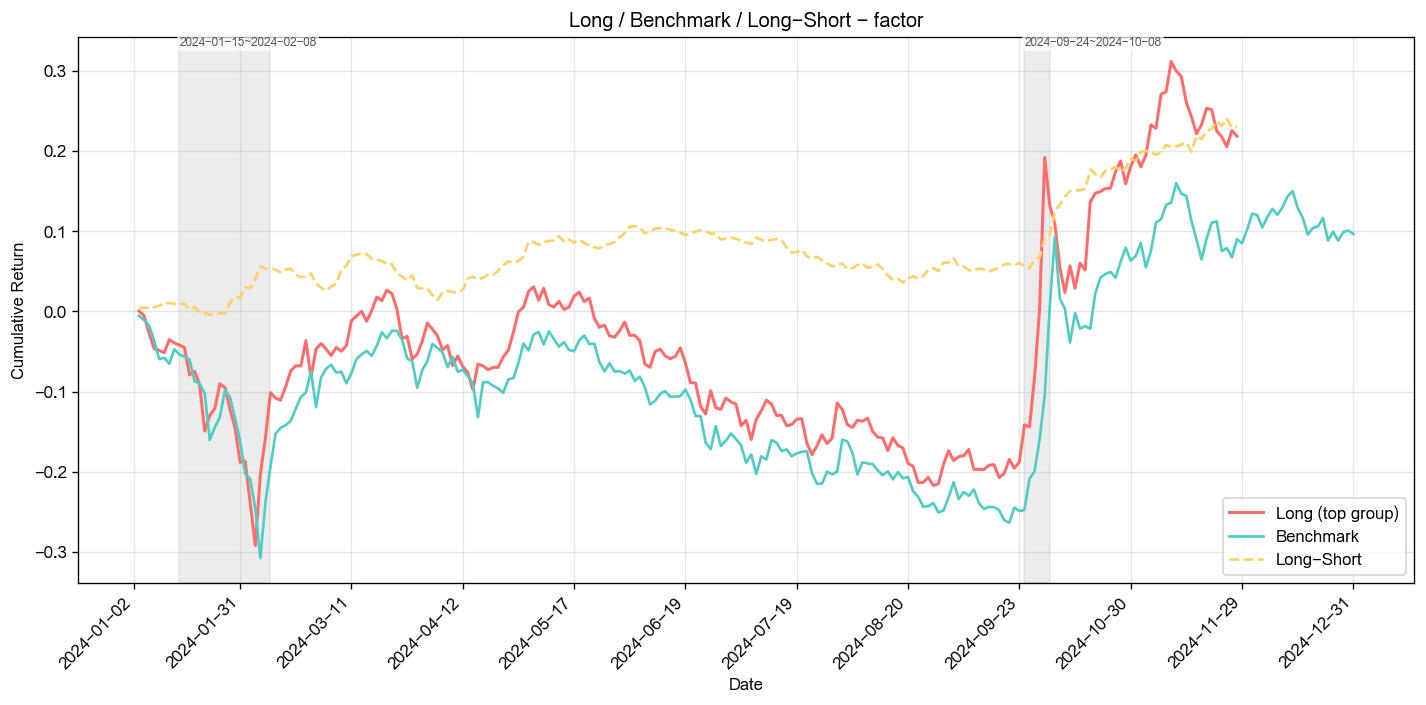
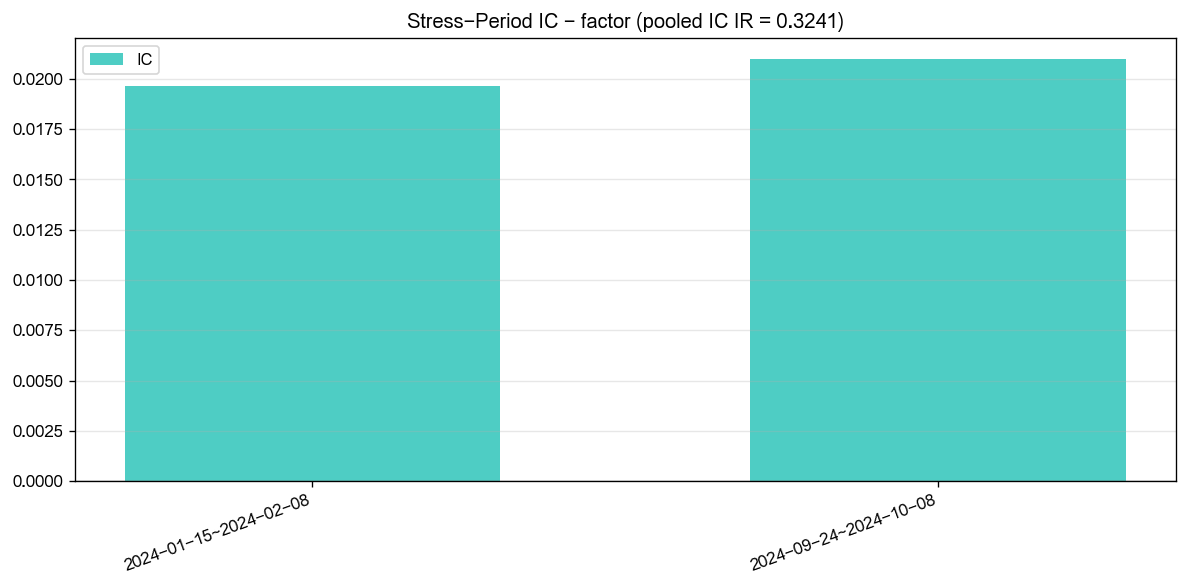
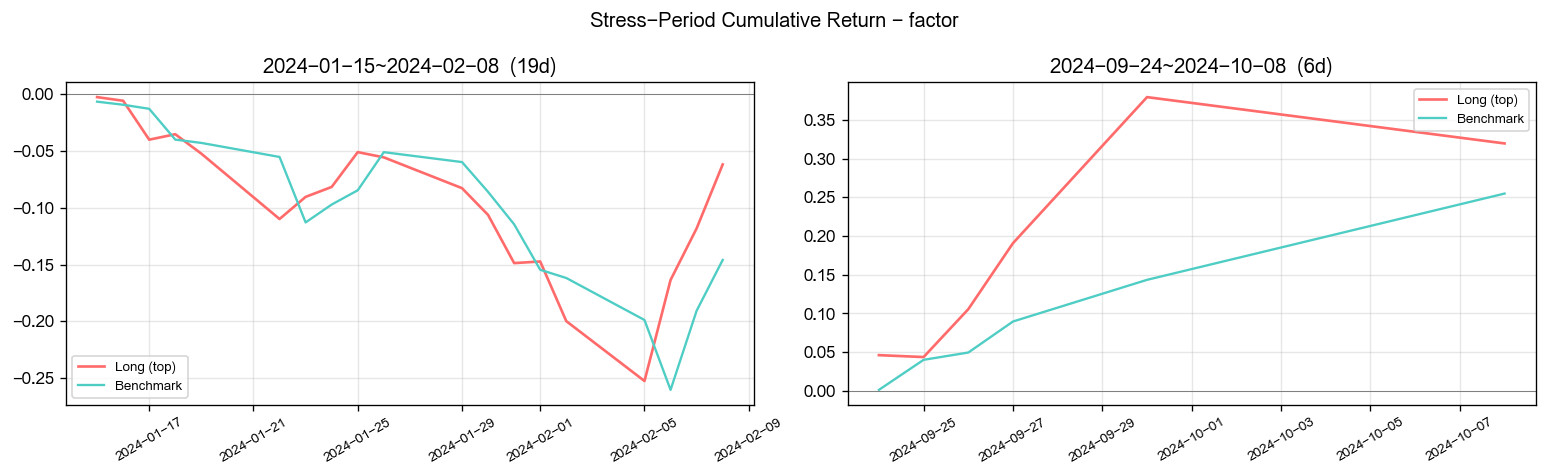

[2026-07-05 22:23:45] [info     ] ========== 因子池回归 ==========
[2026-07-05 22:23:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-05 22:23:46] [info     ] 获取收益率数据, 耗时: 1.3946 秒
[2026-07-05 22:23:48] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.7958 秒
[2026-07-05 22:23:48] [info     ] 统计 回归结果, 耗时: 0.0077 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9270,0.0444,0.0231,1.0000
2,amount,1.7140,0.0185,0.0108,0.9000
3,netflow_amount_main,1.5141,0.0254,0.0168,1.0000
4,gross_profit_rate_ttm,1.5045,0.0069,0.0046,1.0000
5,netflow_amount_rate_main,1.4566,0.0100,0.0069,1.0000
6,net_profit_rate_ttm,1.4523,0.0040,0.0028,0.8000
7,pb,1.4219,0.0097,0.0068,1.0000
8,bias_20,1.4019,0.0290,0.0207,0.9000
9,cci_14,1.3867,0.0338,0.0244,1.0000
10,pe_ttm,1.3093,0.0029,0.0022,0.9000

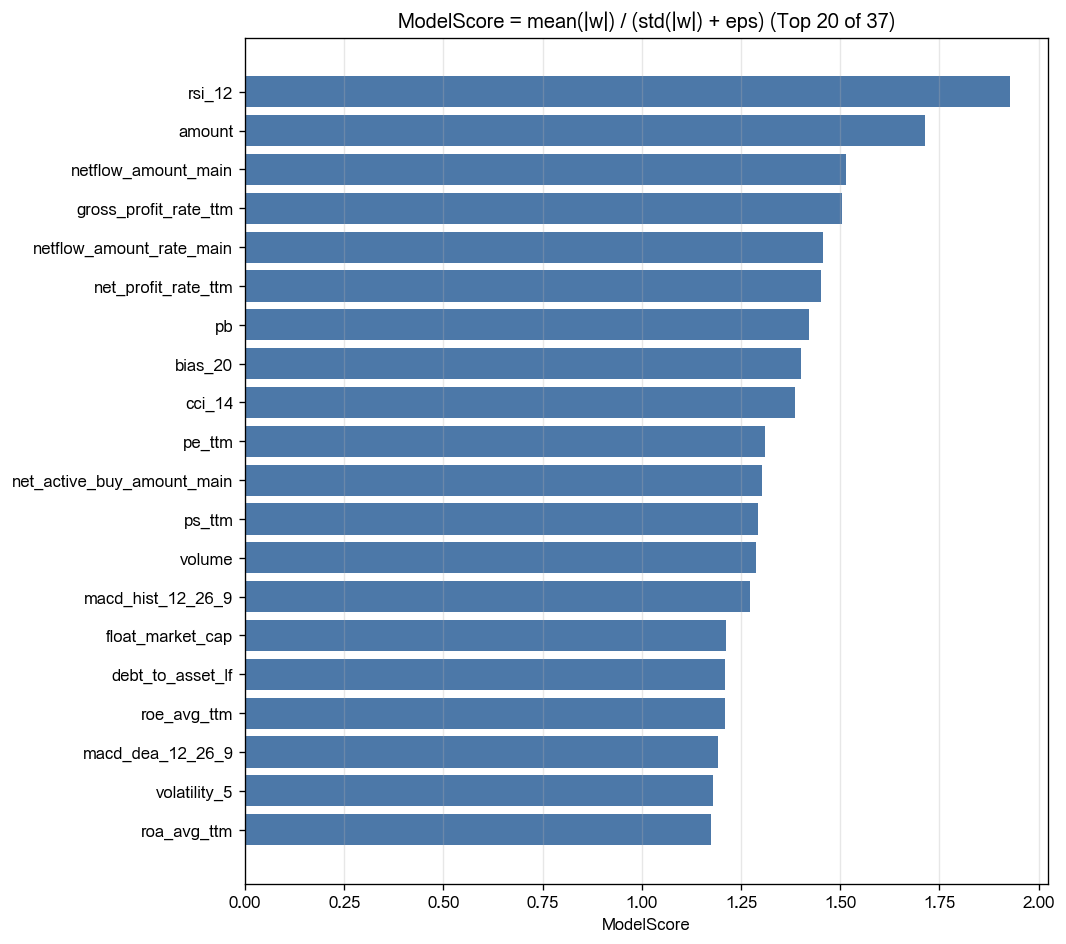
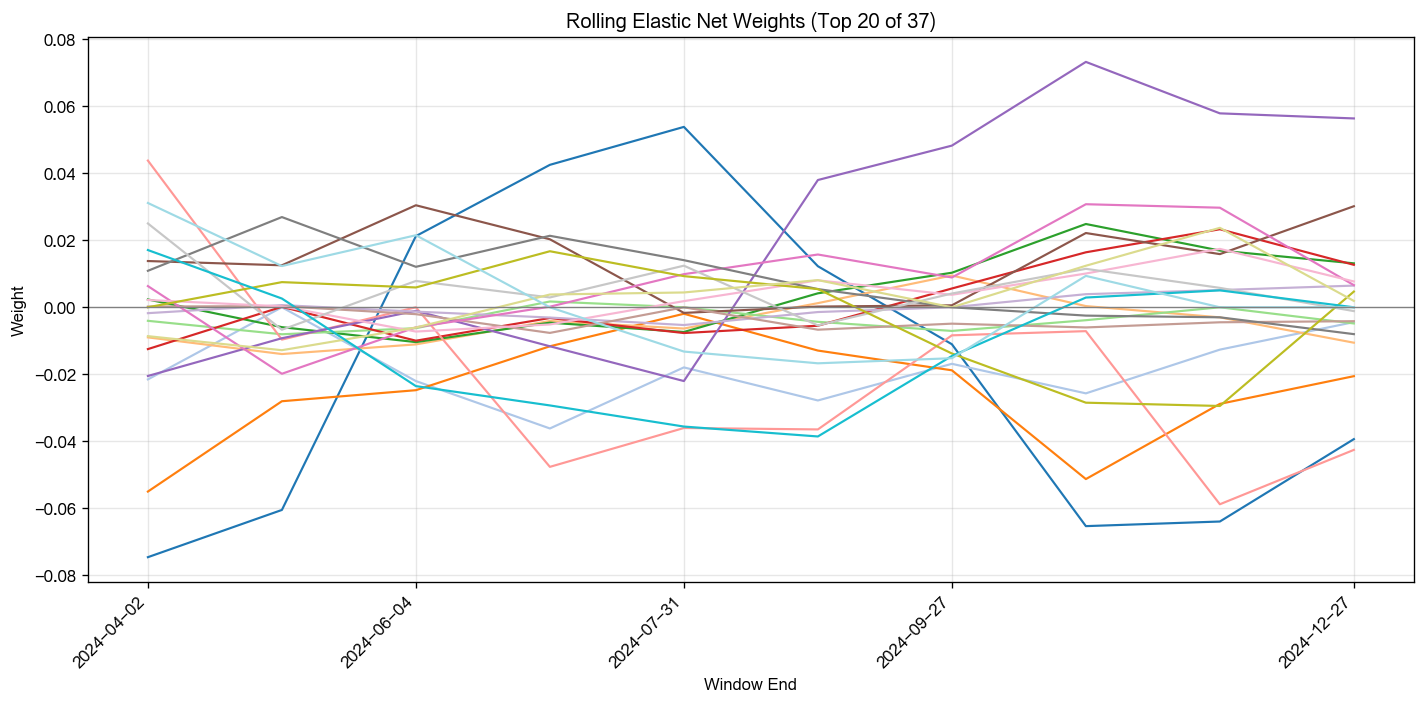
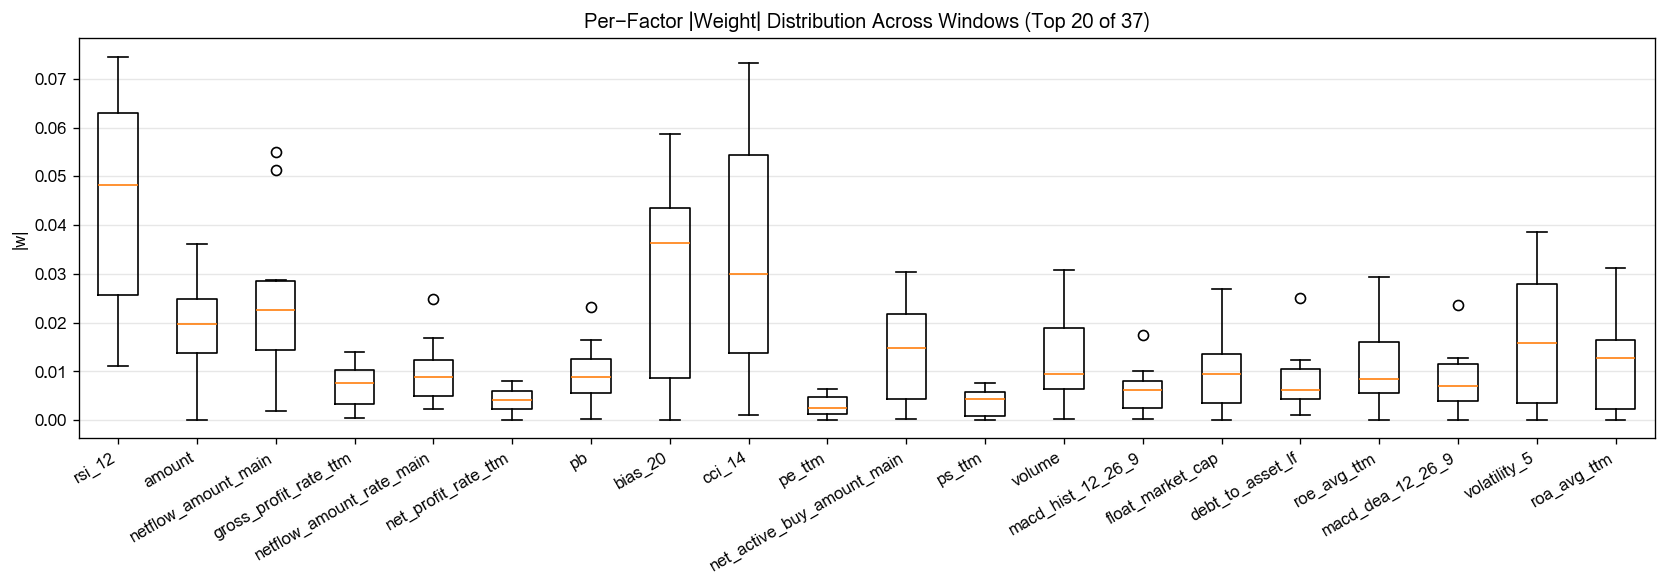
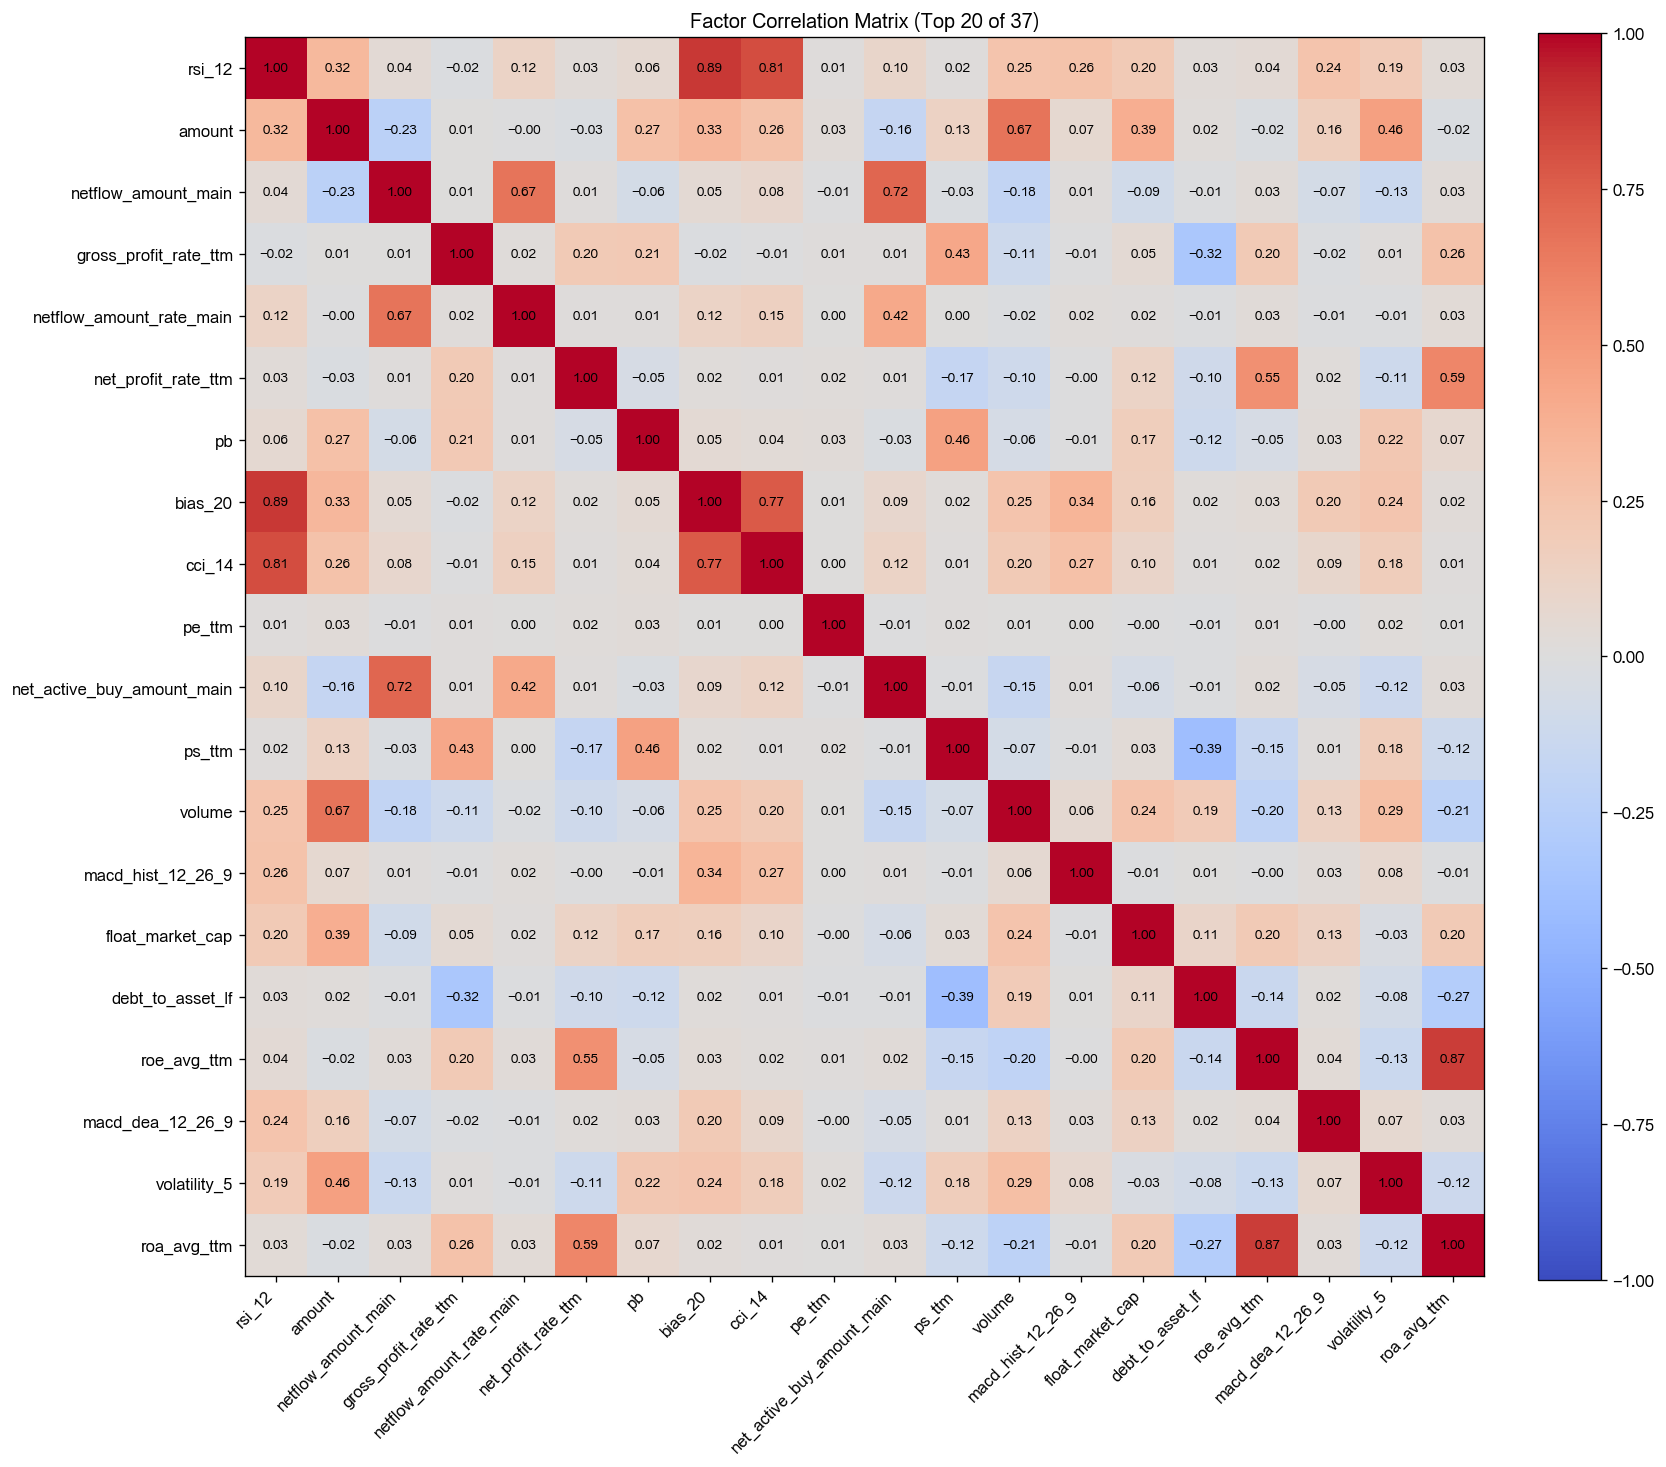

[2026-07-05 22:23:50] [warning  ] 返回的Outputs实例(size=34292648) 大于 64K, 将不会被缓存
[2026-07-05 22:23:50] [info     ] bigalpha_eval.v4 运行完成 [204.886s].


In [2]:
def main(datasources, start_date, end_date):
    """
    随波逐流 + 当前价格相对高位 因子

    返回列必须为 ['date', 'instrument', 'factor']。
    """
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]
    bar1d = datasources.get("bar1d", "bigalpha_2026_bar1d")
    exposure = datasources.get("exposure", "bigalpha_2026_exposure")

    start_dt = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)

    query_start_dt = start_dt - pd.Timedelta(days=120)
    query_start_date = query_start_dt.strftime("%Y-%m-%d %H:%M:%S")
    query_end_date = end_dt.strftime("%Y-%m-%d %H:%M:%S")

    sql = f"""
    WITH daily_return AS (
        SELECT
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS trading_day,
            instrument,
            close / open - 1 AS intraday_return
        FROM {bar1d}
        WHERE date >= TIMESTAMP '{query_start_date}'
        AND date <= TIMESTAMP '{query_end_date}'
        AND open > 0
        AND close > 0
    ),
    reasonable_return AS (
        SELECT
            trading_day,
            instrument,
            AVG(intraday_return) OVER (
                PARTITION BY instrument
                ORDER BY trading_day
                ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
            ) AS reasonable_return
        FROM daily_return
    ),
    minute_base AS (
        SELECT
            date,
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS trading_day,
            instrument,
            open,
            close,
            amount,
            CAST(strftime(date, '%H%M%S') AS INT) AS hhmmss
        FROM {bar1m}
        WHERE date >= TIMESTAMP '{query_start_date}'
        AND date <= TIMESTAMP '{query_end_date}'
        AND open > 0
        AND close > 0
        AND amount >= 0
        AND (
                (CAST(strftime(date, '%H%M%S') AS INT) BETWEEN 93100 AND 113000)
            OR (CAST(strftime(date, '%H%M%S') AS INT) BETWEEN 130100 AND 150000)
        )
    ),
    day_open AS (
        SELECT
            trading_day,
            instrument,
            first(open ORDER BY date) AS day_open
        FROM minute_base
        GROUP BY trading_day, instrument
    ),
    minute_signal AS (
        SELECT
            m.date,
            m.trading_day,
            m.instrument,
            m.close / o.day_open - 1 AS relative_open_return,
            m.amount AS minute_amount
        FROM minute_base m
        INNER JOIN day_open o
            ON m.trading_day = o.trading_day
            AND m.instrument = o.instrument
        WHERE o.day_open > 0
    ),
    daily_high_low AS (
        SELECT
            m.trading_day AS date,
            m.instrument,
            SUM(
                CASE
                    WHEN m.relative_open_return > r.reasonable_return
                    THEN m.minute_amount
                    ELSE 0
                END
            ) AS high_amount,
            SUM(
                CASE
                    WHEN m.relative_open_return < r.reasonable_return
                    THEN m.minute_amount
                    ELSE 0
                END
            ) AS low_amount,
            COUNT(*) AS minute_count,
            MAX(r.reasonable_return) AS reasonable_return,
            last(m.relative_open_return ORDER BY m.date) AS close_relative_open_return
        FROM minute_signal m
        INNER JOIN reasonable_return r
            ON m.trading_day = r.trading_day
            AND m.instrument = r.instrument
        WHERE r.reasonable_return IS NOT NULL
        GROUP BY m.trading_day, m.instrument
    ),
    daily_factor_base AS (
        SELECT
            d.date,
            d.instrument,
            CASE
                WHEN e.float_market_cap > 0
                THEN (d.high_amount - d.low_amount) / e.float_market_cap
                ELSE NULL
            END AS high_low_amount_diff,
            CASE
                WHEN d.close_relative_open_return > d.reasonable_return
                THEN 1
                ELSE 0
            END AS high_position_flag
        FROM daily_high_low d
        INNER JOIN {exposure} e
            ON d.date = CAST(strftime(e.date, '%Y-%m-%d') AS DATETIME)
            AND d.instrument = e.instrument
        WHERE d.minute_count >= 200
    )
    SELECT
        date,
        instrument,
        high_low_amount_diff,
        high_position_flag
    FROM daily_factor_base
    WHERE high_low_amount_diff IS NOT NULL
    ORDER BY date, instrument
    """

    daily_factor = dai.query(
        sql,
        filters={"date": [query_start_date, query_end_date]},
        compression=True,
    ).df()

    if daily_factor.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    daily_factor["date"] = pd.to_datetime(daily_factor["date"])
    daily_factor = daily_factor.replace([np.inf, -np.inf], np.nan)
    daily_factor = daily_factor.dropna(subset=["high_low_amount_diff"])
    daily_factor = daily_factor.sort_values(["date", "instrument"])

    daily_high_state = daily_factor[
        ["date", "instrument", "high_position_flag"]
    ].drop_duplicates()

    trading_days = pd.Series(daily_factor["date"].drop_duplicates()).sort_values()
    month_end_dates = trading_days.groupby(trading_days.dt.to_period("M")).max()
    month_end_dates = month_end_dates[
        (month_end_dates >= query_start_dt.normalize()) &
        (month_end_dates <= end_dt.normalize())
    ]

    result_list = []

    for current_date in month_end_dates:
        window_dates = trading_days[trading_days <= current_date].tail(20)
        if len(window_dates) < 20:
            continue

        window_data = daily_factor[daily_factor["date"].isin(window_dates)]
        pivot_data = window_data.pivot(
            index="date",
            columns="instrument",
            values="high_low_amount_diff",
        )

        rank_data = pivot_data.rank(axis=0)
        corr_data = rank_data.corr(method="pearson", min_periods=10).abs()
        if corr_data.empty:
            continue

        corr_values = corr_data.values
        np.fill_diagonal(corr_values, np.nan)

        factor = corr_data.mean(axis=1, skipna=True)
        factor = factor.dropna()
        if factor.empty:
            continue

        month_result = factor.reset_index()
        month_result.columns = ["instrument", "wave_factor"]
        month_result["date"] = current_date
        result_list.append(month_result[["date", "instrument", "wave_factor"]])

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [query_start_date, end_date]},
        compression=True,
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"])

    if result_list:
        factor_data = pd.concat(result_list, ignore_index=True)
    else:
        factor_data = pd.DataFrame(columns=["date", "instrument", "wave_factor"])

    factor_data = pd.merge(
        stk_pool,
        factor_data,
        how="left",
        on=["date", "instrument"],
    )

    factor_data = factor_data.sort_values(["instrument", "date"])
    factor_data["wave_factor"] = factor_data.groupby("instrument")["wave_factor"].ffill()

    factor_data = pd.merge(
        factor_data,
        daily_high_state,
        how="left",
        on=["date", "instrument"],
    )

    factor_data["wave_factor"] = factor_data["wave_factor"].fillna(0)
    factor_data["high_position_flag"] = factor_data["high_position_flag"].fillna(0)
    factor_data["factor"] = factor_data["wave_factor"] * factor_data["high_position_flag"]

    factor_data = factor_data[
        (factor_data["date"] >= start_dt.normalize()) &
        (factor_data["date"] <= end_dt.normalize())
    ]

    factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
    factor_data["factor"] = factor_data["factor"].fillna(0)
    factor_data["factor"] = -factor_data["factor"]

    return factor_data[["date", "instrument", "factor"]]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {
    "bar1m": "bigalpha_2026_stock_bar1m",
    "bar1d": "bigalpha_2026_bar1d",
    "exposure": "bigalpha_2026_exposure",
}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
